In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, make_scorer
from sklearn.inspection import permutation_importance
from sklearn.model_selection import cross_validate

from catboost import CatBoostRegressor

plt.rcParams['figure.dpi'] = 150

### Работаем  с набором данных про подсеточные интенсивные осадки [DCIPP  (Dataset on Convective Intensive Precipitation Predictors)](https://github.com/mvarentsov/ML4hydromet-2025/edit/main/DCIPP_dataset-description.md)

In [2]:
df = pd.read_csv ('../datasets/DCIPP/Obs-ERA5_СPrec_dataset.csv', parse_dates=['date'], index_col=['date'])

In [3]:
df

,year,month,day,nans,range,max,mean,std,svar,kurt,...,E5Lq_500[g/kg],E5Lw_850[Pa/s],E5Lw_700[Pa/s],E5Lw_500[Pa/s],E5Ld_950[10^5/s],E5Ld_300[10^5/s],E5Ld_500[10^5/s],E5Lz_500[km],E5Lz_700[km],E5Lz_850[k]
date,,,,,,,,,,,,,,,,,,,,,
1989-05-01,1989,5,1,0,0.4,0.4,0.01481,0.07698,0.00593,25.03846,...,0.63209,-0.10120,-0.06646,-0.07441,-1.28371,0.84708,-0.21159,5.66631,3.06995,1.49678
1989-05-02,1989,5,2,0,4.9,4.9,0.68519,1.35127,1.82593,5.65523,...,0.97320,-0.11413,-0.15533,-0.19135,-0.79981,1.09787,-0.04874,5.61616,3.03750,1.47336
1989-05-03,1989,5,3,0,21.8,21.8,4.30741,4.67456,21.85148,8.80583,...,0.67237,-0.07146,-0.09326,-0.08508,-0.91296,0.50321,0.19399,5.54298,2.98579,1.43421
1989-05-04,1989,5,4,0,5.7,5.7,0.55185,1.55820,2.42798,8.09123,...,0.57976,-0.01823,0.00713,0.03115,-0.25295,-0.59028,-0.00523,5.54607,2.98530,1.43596
1989-05-05,1989,5,5,0,9.0,9.0,1.55556,2.33787,5.46564,5.54808,...,0.61954,0.00242,0.01053,-0.00686,0.22766,-0.08115,-0.07807,5.49325,2.94660,1.40529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-23,2020,9,23,0,0.5,0.5,0.01852,0.09623,0.00926,25.03846,...,0.42750,0.00651,-0.01094,-0.02169,0.00678,0.50250,-0.08272,5.76177,3.10467,1.50473
2020-09-27,2020,9,27,0,12.6,12.6,0.49259,2.42153,5.86379,24.96282,...,1.16624,0.02095,-0.00047,-0.01080,1.04508,-0.10586,-0.12718,5.76636,3.15441,1.56713
2020-09-28,2020,9,28,0,5.7,5.7,1.40370,1.25007,1.56268,6.13771,...,1.14432,-0.05460,-0.08979,-0.15949,-0.22017,1.02297,-0.22106,5.74250,3.13718,1.56146


### Целевая переменная - максимальная сумма осадков по региону, предикторы - осредненные данные ERA5

In [4]:
df_Xy = df.iloc[:,26:] 
df_Xy = df_Xy[[c for c in df_Xy.columns if 'E5Stp' not in c or 'tpsmean' in c]]
df_Xy = df_Xy.rename(columns = {c:c.replace('E5L', '').replace('E5S', '') for c in df_Xy.columns})

df_Xy = df_Xy.sort_index(axis=1)

df_Xy = pd.concat([df['max'], df_Xy], axis=1).rename(columns = {'max':'y_max'})


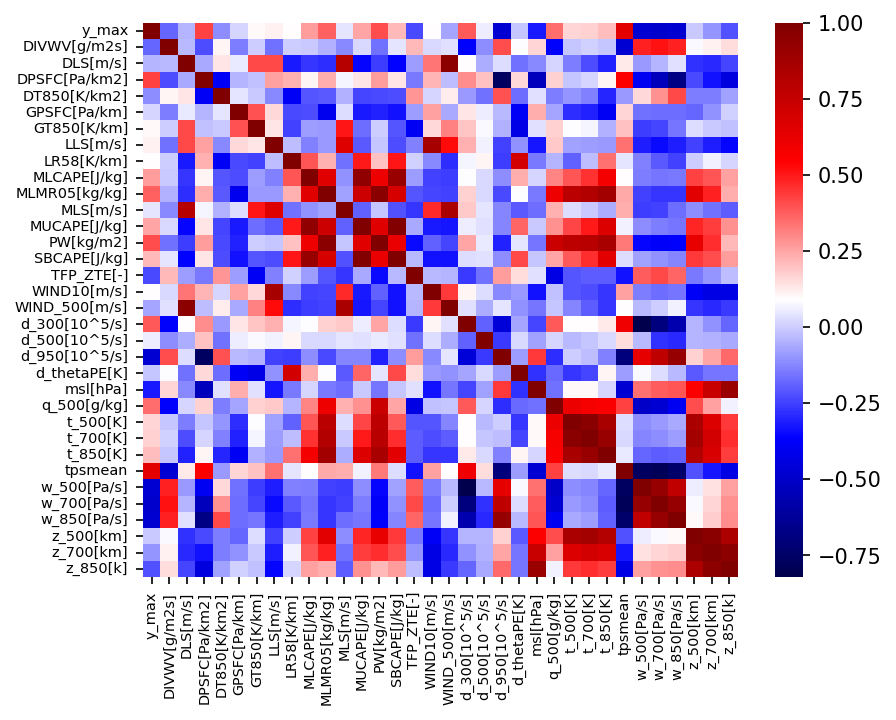

In [5]:
ax = sns.heatmap(df_Xy.corr(), xticklabels=True, yticklabels=True, cmap='seismic')
ax.tick_params(axis='both', labelsize='x-small') 

### Применим метод главных компонент к переменным, характеризующим барическое поле (геопотенциал и приземное давление)

In [8]:
#baric_cols = [c for c in df_Xy.columns if 'msl' in c or 'z_' in c or 't_' in c]
cols4PCA = ['msl[hPa]','z_500[km]','z_700[km]','z_850[k]'] #+ ['t_500[K]','t_700[K]','t_850[K]']
#cols4PCA = [c for c in df_Xy.columns[1:]]

pca_scaler = StandardScaler()
X4pca =  df_Xy[cols4PCA].copy().to_numpy()
X4pca_scaled = pca_scaler.fit_transform(X4pca)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X4pca_scaled)
print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Explained variance ratio (cumulative): {pca.explained_variance_ratio_.cumsum()}')


# df_pca = pd.DataFrame({'feature': cols4PCA} | {f'PCA{i}_weight': pca.components_[i,:] for i in range(pca.components_.shape[0])})
# display(df_pca)

Explained variance ratio: [0.87226654 0.12393465]
Explained variance ratio (cumulative): [0.87226654 0.99620119]


### Посмотрим, что получается при обратной трансформации


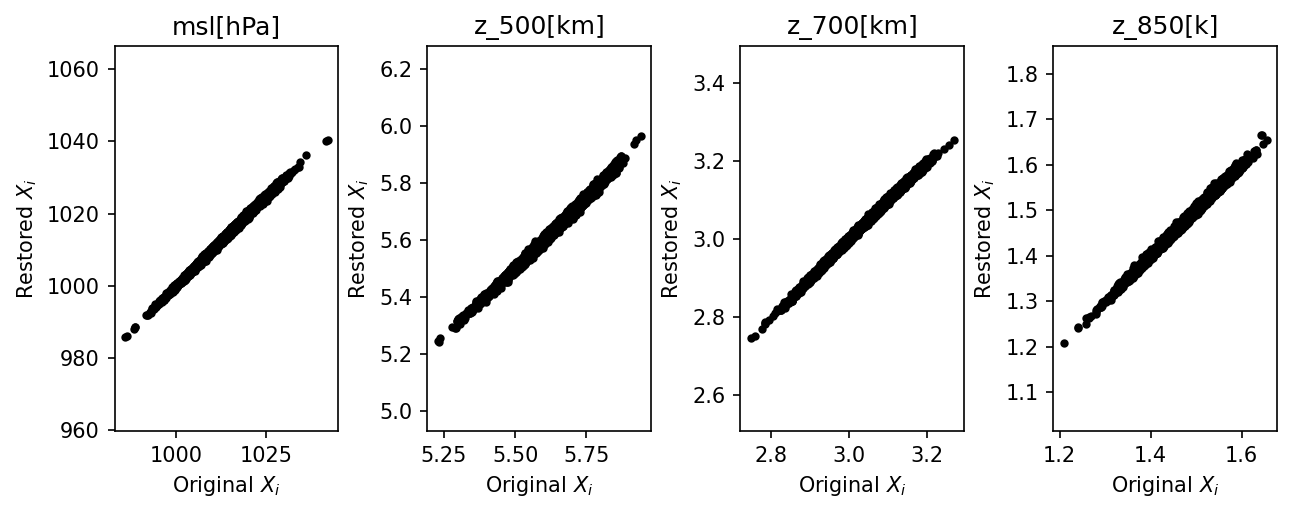

In [9]:
X4pca_restored = pca_scaler.inverse_transform(pca.inverse_transform(X_pca))

fig, ax = plt.subplots(1, X4pca.shape[1], figsize=[10,3.33])
plt.subplots_adjust(wspace=0.4)
for i in range(X4pca.shape[1]): 
    ax[i].plot(X4pca[:,i], X4pca_restored[:,i], '.k') 
    ax[i].axis('equal')
    ax[i].set_title(cols4PCA[i])
    ax[i].set_xlabel('Original $X_i$')
    ax[i].set_ylabel('Restored $X_i$')


### Обучим модель регрессии с использованием PCA-признаков и или без них

In [ ]:
X = df_Xy.drop(columns='y_max')
y = df_Xy['y_max']

use_pca = True

if use_pca:
    X = X.drop(columns = cols4PCA)

    for i in range(X_pca.shape[1]): 
        X[f'baric_PCA{i+1}'] = X_pca[:,i]

   
model = Pipeline ((('scaler', StandardScaler()), 
                   ('regressor', Ridge())))

#model = CatBoostRegressor(silent=True)

model.fit(X, y)

cv_results = cross_validate (model, X, y, cv=5, scoring=make_scorer(r2_score), return_train_score = True)

In [11]:
print (f'R2 = {cv_results['test_score'].mean():.3f} +- {cv_results['test_score'].std():.3f}')


R2 = 0.501 +- 0.019


### Исследуем значимость признаков при с использованием PCA-признаков и или без них

In [12]:
perm_imp = permutation_importance(model, X, y,
                                  n_repeats=30,
                                  random_state=42)


Text(0.5, 0.98, 'alpha = 1.0, R2 = 0.501, use_pca = False')

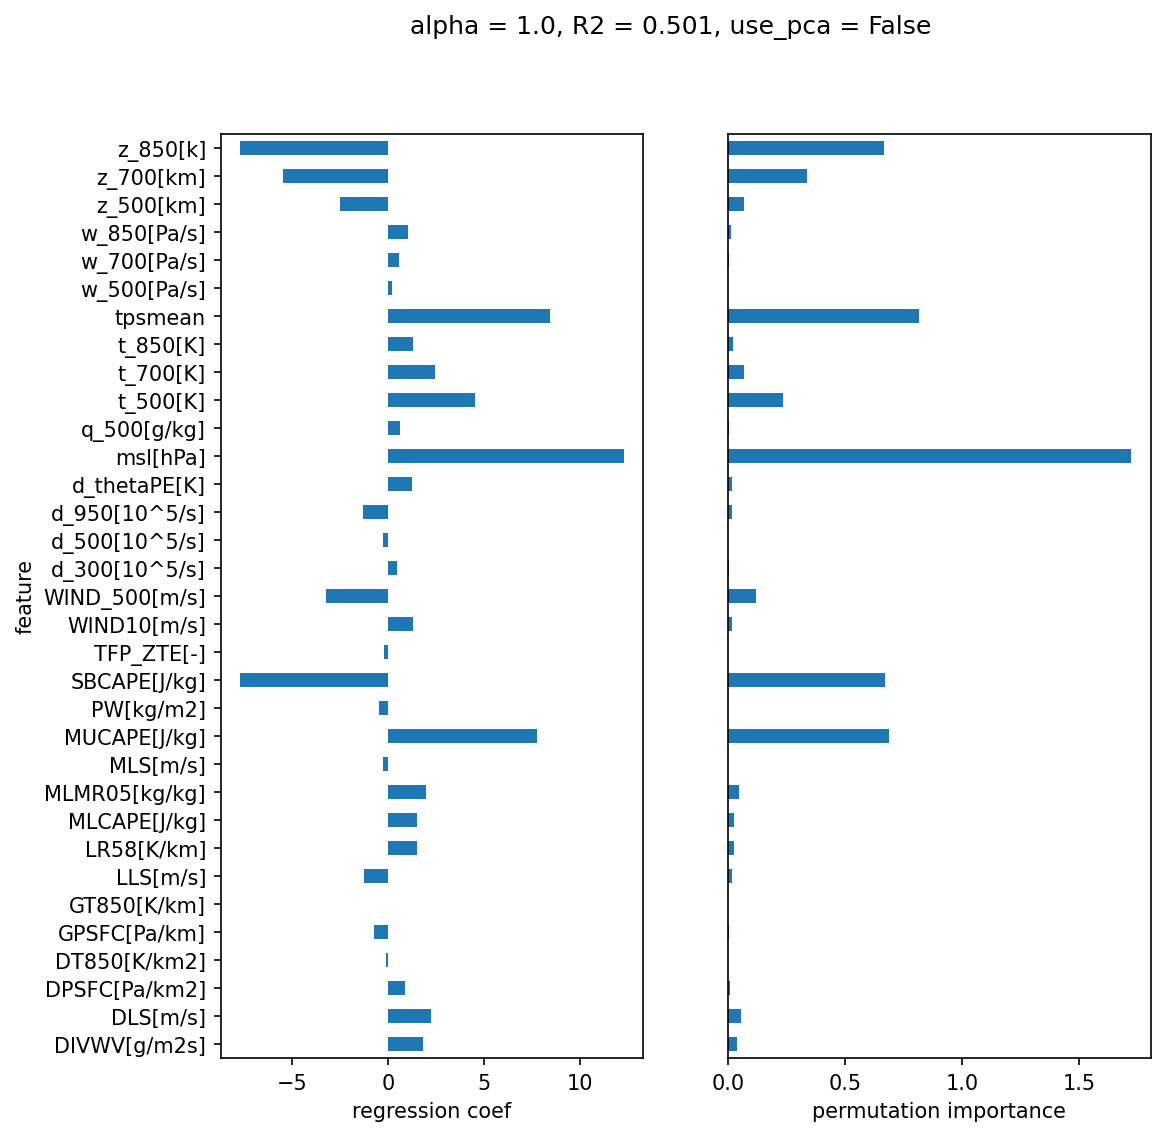

In [13]:
imp_df = pd.DataFrame({'feature': X.columns, 'perm_imp':perm_imp['importances_mean'], 'coef':model['regressor'].coef_}).set_index('feature')

fig, ax = plt.subplots (1, 2, figsize = (8,8))
imp_df['coef'].plot.barh(ax = ax[0])
imp_df['perm_imp'].plot.barh(ax = ax[1])
ax[1].set_yticks([])
ax[1].set_ylabel('')
ax[1].set_xlabel('permutation importance')
ax[0].set_xlabel('regression coef')
plt.suptitle (f'alpha = {model['regressor'].alpha}, R2 = {cv_results['test_score'].mean():.3f}, use_pca = {use_pca}')